In [1]:
import sys
sys.path.append(r"C:\Projects\anomaly-detection-fundamentals\Modeling\Code")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from eval_protocol import time_split_per_kpi, evaluate_protocol
from preprocess import preprocess_all

In [2]:
KPI_PREFIX = "02e99bd4"   # đổi tại đây để chạy KPI khác
df = pd.read_csv(r"C:\Projects\anomaly-detection-fundamentals\Data\train.csv")
df.columns = ["timestamp", "value", "label", "kpi"]
kpi = [k for k in df.kpi.unique() if k.startswith(KPI_PREFIX)][0]

In [4]:
g = df[df.kpi == kpi].copy()
step = int(pd.Series(np.diff(np.sort(g.timestamp.values))).mode().iloc[0])   # chu kỳ lấy mẫu (giây)
g = time_split_per_kpi(g, train_frac=0.6, val_frac=0.2)                       # chia theo THỜI GIAN
p = preprocess_all(g, max_gap_points=15, norm_method="robust").sort_values("timestamp").reset_index(drop=True)

In [9]:
p

,timestamp,value,label,kpi,split,filled,masked,value_filled,segment,value_norm
0,1493568000,1.901639,0,02e99bd4f6cfb33f,train,False,False,1.901639,0,-0.203747
1,1493568060,1.786885,0,02e99bd4f6cfb33f,train,False,False,1.786885,0,-0.384140
2,1493568120,2.000000,0,02e99bd4f6cfb33f,train,False,False,2.000000,0,-0.049125
3,1493568180,1.885246,0,02e99bd4f6cfb33f,train,False,False,1.885246,0,-0.229517
4,1493568240,1.819672,0,02e99bd4f6cfb33f,train,False,False,1.819672,0,-0.332599
...,...,...,...,...,...,...,...,...,...,...
131790,1501475400,2.684211,0,02e99bd4f6cfb33f,test,False,False,2.684211,21,1.026449
131791,1501475460,2.526316,0,02e99bd4f6cfb33f,test,False,False,2.526316,21,0.778240
131792,1501475520,2.614035,0,02e99bd4f6cfb33f,test,False,False,2.614035,21,0.916134
131793,1501475580,2.736842,0,02e99bd4f6cfb33f,test,False,False,2.736842,21,1.109186


In [7]:
print("KPI:", kpi, "| tổng điểm:", len(p), "| step:", step, "s")
print("số segment liên tục:", p.segment.nunique(), "| điểm bị mask (gap dài):", int(p.masked.sum()))
for s in ["train", "val", "test"]:
    sub = p[p.split == s]
    print(f"  {s:5s}: {len(sub):6d} điểm | anomaly={int(sub.label.sum()):5d} ({sub.label.mean()*100:.2f}%)")

KPI: 02e99bd4f6cfb33f | tổng điểm: 131795 | step: 60 s
số segment liên tục: 22 | điểm bị mask (gap dài): 3183
  train:  80169 điểm | anomaly= 8444 (10.53%)
  val  :  25718 điểm | anomaly=  724 (2.82%)
  test :  25908 điểm | anomaly= 1382 (5.33%)


In [8]:
seg_sizes = p.groupby("segment").size().sort_values(ascending=False)
print("Kích thước các segment (điểm):")
print(seg_sizes.to_string())
print(f"\nSegment lớn nhất: {seg_sizes.iloc[0]} điểm "
      f"({seg_sizes.iloc[0]/seg_sizes.sum()*100:.1f}% dữ liệu)")

Kích thước các segment (điểm):
segment
18    56793
21    23959
4      6120
9      5220
5      4980
0      3660
16     3501
6      3482
10     3300
3      3120
11     3060
15     2940
12     1920
8      1738
17     1661
1      1500
7      1380
2      1320
20     1127
19      414
13      300
14      300

Segment lớn nhất: 56793 điểm (43.1% dữ liệu)


In [10]:
from statsmodels.tsa.stattools import adfuller

# Lấy segment liên tục dài nhất NẰM TRONG train (chỉ điểm thật, bỏ NaN)
tr = p[(p.split == "train") & (p.value_filled.notna())]
seg_id = tr.groupby("segment").size().idxmax()
s_train = p[(p.segment == seg_id) & (p.split == "train") & (p.value_filled.notna())] \
            .value_filled.reset_index(drop=True)
print(f"Segment train dài nhất: id={seg_id} | độ dài={len(s_train)} điểm liên tục\n")

def adf_test(x, name):
    x = x.dropna()
    stat, pval = adfuller(x, autolag="AIC")[:2]
    print(f"  {name:22s}: ADF={stat:8.3f} | p-value={pval:.4f} -> {'DỪNG' if pval < 0.05 else 'CHƯA dừng'}")
    return pval

Segment train dài nhất: id=18 | độ dài=30667 điểm liên tục



In [12]:
from statsmodels.tsa.stattools import adfuller, kpss
import warnings

def stationarity_test(x, name):
    x = x.dropna()
    adf_p = adfuller(x, autolag="AIC")[1]
    with warnings.catch_warnings():           # KPSS cảnh báo khi p ngoài bảng tra -> bỏ qua
        warnings.simplefilter("ignore")
        kpss_p = kpss(x, regression="c", nlags="auto")[1]
    adf_stat = "dừng" if adf_p < 0.05 else "chưa dừng"
    kpss_stat = "dừng" if kpss_p > 0.05 else "chưa dừng"
    print(f"  {name:6s}: ADF p={adf_p:.4f} ({adf_stat}) | KPSS p={kpss_p:.4f} ({kpss_stat})")
    return adf_p, kpss_p

adf_p, kpss_p = stationarity_test(s_train, "d=0")
if adf_p < 0.05 and kpss_p > 0.05:
    d = 0; print("\n=> Cả hai đều dừng -> d = 0")
elif adf_p < 0.05 and kpss_p <= 0.05:
    d = 0; print("\n=> TREND-STATIONARY (ADF dừng, KPSS không) -> d=0 nhưng PHẢI khử mùa vụ/xu hướng ở Bước 3")
elif adf_p >= 0.05 and kpss_p <= 0.05:
    d = 1; print("\n=> DIFFERENCE-STATIONARY -> cần sai phân, thử d = 1")
else:
    d = 1; print("\n=> Không rõ ràng -> thử sai phân d = 1 rồi test lại")

  d=0   : ADF p=0.0000 (dừng) | KPSS p=0.0100 (chưa dừng)

=> TREND-STATIONARY (ADF dừng, KPSS không) -> d=0 nhưng PHẢI khử mùa vụ/xu hướng ở Bước 3


In [13]:
ts = p.timestamp.values
xn = pd.Series(p.value_norm.values.astype(float))
tr_mask = (p.split == "train").values & p.value_filled.notna().values
mod = ((ts % 86400) // 60).astype(int)          # phút-trong-ngày: 0..1439

# Profile mùa vụ: median theo phút-trong-ngày, FIT trên TRAIN
seasonal_profile = pd.Series(xn[tr_mask].values).groupby(mod[tr_mask]).median()
seasonal = pd.Series(mod).map(seasonal_profile)  # áp cho toàn bộ train/val/test
p["deseason"] = (xn - seasonal).values

print(f"Biên độ profile mùa vụ: {seasonal_profile.min():.3f} .. {seasonal_profile.max():.3f} "
      f"(chênh {seasonal_profile.max() - seasonal_profile.min():.3f})")
print(f"std trước khử mùa vụ: {np.nanstd(xn[tr_mask]):.3f} | sau: {np.nanstd(p['deseason'].values[tr_mask]):.3f}")

Biên độ profile mùa vụ: -1.670 .. 0.786 (chênh 2.456)
std trước khử mùa vụ: 0.987 | sau: 0.498


  gốc     : ADF p=0.0000 (dừng) | KPSS p=0.0100 (chưa dừng)
  deseason: ADF p=0.0000 (dừng) | KPSS p=0.0100 (chưa dừng)

(KPSS có thể vẫn báo 'chưa dừng' do n lớn — ADF mạnh mẽ khẳng định dừng, giữ d=0, KHÔNG sai phân thêm.)


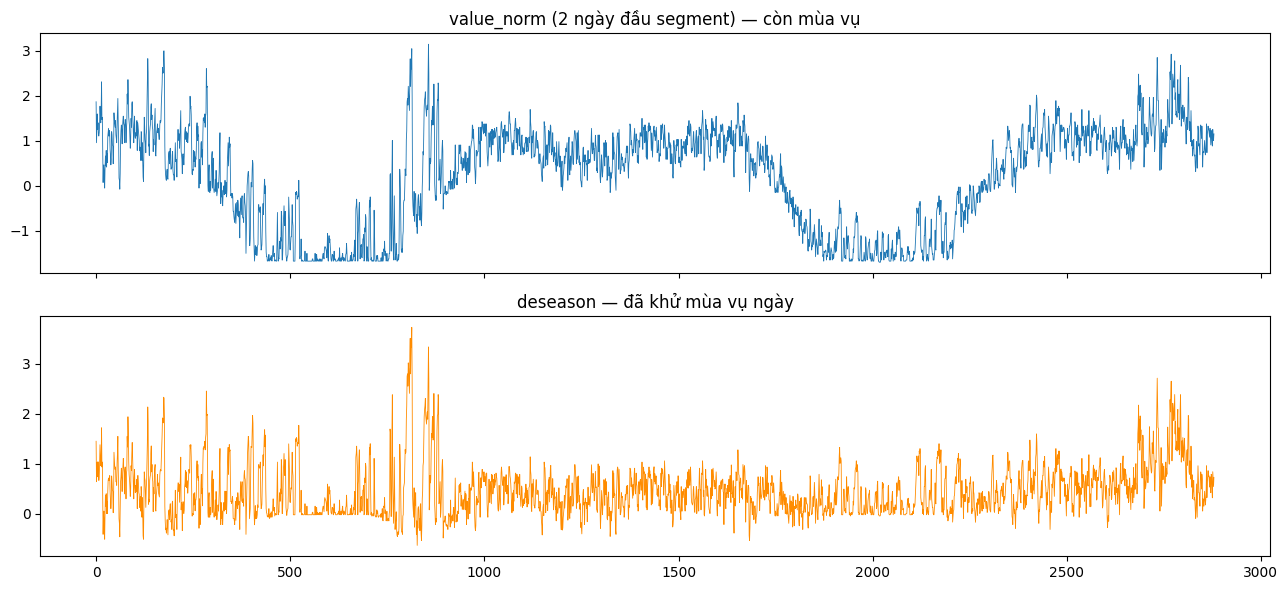

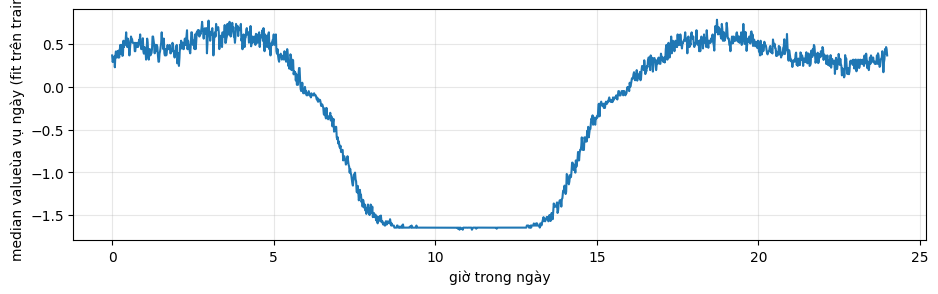

In [15]:
sel = ((p.segment == seg_id) & (p.split == "train") & (p.value_filled.notna())).values
stationarity_test(pd.Series(xn[sel]),           "gốc     ")
stationarity_test(pd.Series(p['deseason'].values[sel]), "deseason")
print("\n(KPSS có thể vẫn báo 'chưa dừng' do n lớn — ADF mạnh mẽ khẳng định dừng, giữ d=0, KHÔNG sai phân thêm.)")

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(xn[sel].values[:2880], lw=0.6);            ax[0].set_title("value_norm (2 ngày đầu segment) — còn mùa vụ")
ax[1].plot(p['deseason'].values[sel][:2880], lw=0.6, color="darkorange"); ax[1].set_title("deseason — đã khử mùa vụ ngày")
plt.tight_layout(); plt.show()

# Profile mùa vụ 1 ngày
plt.figure(figsize=(11, 3))
plt.plot(seasonal_profile.index / 60, seasonal_profile.values)   # trục x = giờ trong ngày
plt.xlabel("giờ trong ngày"); plt.ylabel("median valueùa vụ ngày (fit trên train)")
plt.grid(alpha=0.3); plt.show()

chuỗi deseason train: 30667 điểm
PACF (lag 1-8): [0.824 0.063 0.188 0.101 0.091 0.089 0.028 0.074]
ACF  (lag 1-8): [0.824 0.7   0.653 0.625 0.604 0.592 0.57  0.559]


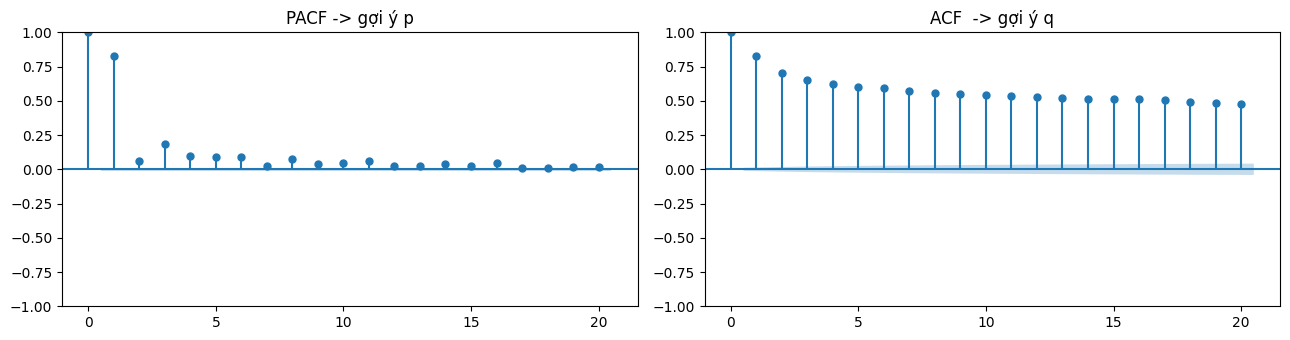

In [16]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

s_des = p[(p.segment == seg_id) & (p.split == "train") & p.deseason.notna()].deseason.reset_index(drop=True)
print("chuỗi deseason train:", len(s_des), "điểm")
print("PACF (lag 1-8):", np.round(pacf(s_des, nlags=8)[1:], 3))
print("ACF  (lag 1-8):", np.round(acf(s_des, nlags=8)[1:], 3))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.5))
plot_pacf(s_des, lags=20, ax=ax[0], method="ywm"); ax[0].set_title("PACF -> gợi ý p")
plot_acf(s_des, lags=20, ax=ax[1]);                ax[1].set_title("ACF  -> gợi ý q")
plt.tight_layout(); plt.show()

In [17]:
import time
from statsmodels.tsa.arima.model import ARIMA
import warnings; warnings.filterwarnings("ignore")

t0 = time.time(); grid = []
for pp in range(4):
    for qq in range(4):
        try:
            aic = ARIMA(s_des, order=(pp, 0, qq)).fit().aic
            grid.append((pp, qq, aic))
            print(f"  ARIMA({pp},0,{qq}) AIC={aic:8.1f}")
        except Exception:
            print(f"  ARIMA({pp},0,{qq}) lỗi hội tụ")
grid.sort(key=lambda r: r[2])
P, Q = grid[0][0], grid[0][1]
print(f"\n=> AIC thấp nhất: ARIMA({P},0,{Q}) (AIC={grid[0][2]:.1f}) | grid mất {time.time()-t0:.0f}s")

  ARIMA(0,0,0) AIC= 52339.0
  ARIMA(0,0,1) AIC= 32147.4
  ARIMA(0,0,2) AIC= 25583.5
  ARIMA(0,0,3) AIC= 22758.3
  ARIMA(1,0,0) AIC= 17452.3
  ARIMA(1,0,1) AIC= 17217.9
  ARIMA(1,0,2) AIC= 15341.7
  ARIMA(1,0,3) AIC= 15010.6
  ARIMA(2,0,0) AIC= 17331.3
  ARIMA(2,0,1) AIC= 17443.5
  ARIMA(2,0,2) AIC= 14849.7
  ARIMA(2,0,3) AIC= 14678.6
  ARIMA(3,0,0) AIC= 16223.1
  ARIMA(3,0,1) AIC= 14899.7
  ARIMA(3,0,2) AIC= 14808.1
  ARIMA(3,0,3) AIC= 14840.8

=> AIC thấp nhất: ARIMA(2,0,3) (AIC=14678.6) | grid mất 140s


In [18]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.arima.model import ARIMA
import warnings; warnings.filterwarnings("ignore")

ORDER = (2, 0, 0)   # chốt ở Bước 4 (đơn giản, AP val ~ tương đương model phức tạp, nhanh 19x)
tr_s = p[(p.segment == seg_id) & (p.split == "train") & p.deseason.notna()].deseason.reset_index(drop=True)
model = ARIMA(tr_s, order=ORDER).fit()
mu, a1, a2 = model.params["const"], model.params["ar.L1"], model.params["ar.L2"]
print(f"ARIMA{ORDER} params: μ={mu:.4f}, φ1={a1:.4f}, φ2={a2:.4f}")

ARIMA(2, 0, 0) params: μ=0.0880, φ1=0.7721, φ2=0.0633


In [19]:
ds, seg = p["deseason"], p["segment"]
lag1 = ds.groupby(seg).shift(1)        # y_{t-1} trong cùng segment
lag2 = ds.groupby(seg).shift(2)        # y_{t-2} trong cùng segment
pred = mu + a1 * (lag1 - mu) + a2 * (lag2 - mu)
resid = ds - pred
valid = ds.notna() & lag1.notna() & lag2.notna()     # bỏ 2 điểm đầu mỗi segment & điểm cạnh gap

# σ robust từ residual TRAIN (không nhìn val/test)
rtr = resid[valid.values & (p.split == "train").values].dropna()
sigma = np.median(np.abs(rtr - rtr.median())) * 1.4826
p["score"] = (resid.abs() / sigma).where(valid).values
print(f"σ (MAD robust, train) = {sigma:.4f} | điểm valid: {int(valid.sum())}/{len(p)}")

σ (MAD robust, train) = 0.1816 | điểm valid: 128568/131795


In [20]:
from eval_protocol import evaluate_protocol

y = p.label.values.astype(int)
vm = (p.split == "val").values  & valid.values
tm = (p.split == "test").values & valid.values
r = evaluate_protocol(y[vm], p.score.values[vm], y[tm], p.score.values[tm], beta=1.0, step_s=step)

print(f"=== ARIMA{ORDER} | KPI {kpi[:8]} ===")
print(f"  AP_test = {r['AP_pw']:.3f}")
print(f"  PW : P={r['PW']['precision']:.3f} R={r['PW']['recall']:.3f} F1={r['PW']['fbeta']:.3f}")
print(f"  PA : P={r['PA']['precision']:.3f} R={r['PA']['recall']:.3f} F1={r['PA']['fbeta']:.3f}")
print(f"  TTD: {r['TTD']}")

=== ARIMA(2, 0, 0) | KPI 02e99bd4 ===
  AP_test = 0.481
  PW : P=0.663 R=0.384 F1=0.486
  PA : P=0.947 R=1.000 F1=0.973
  TTD: {'ttd_sec_mean': 100.0, 'detected_segments': 9, 'total_segments': 9}


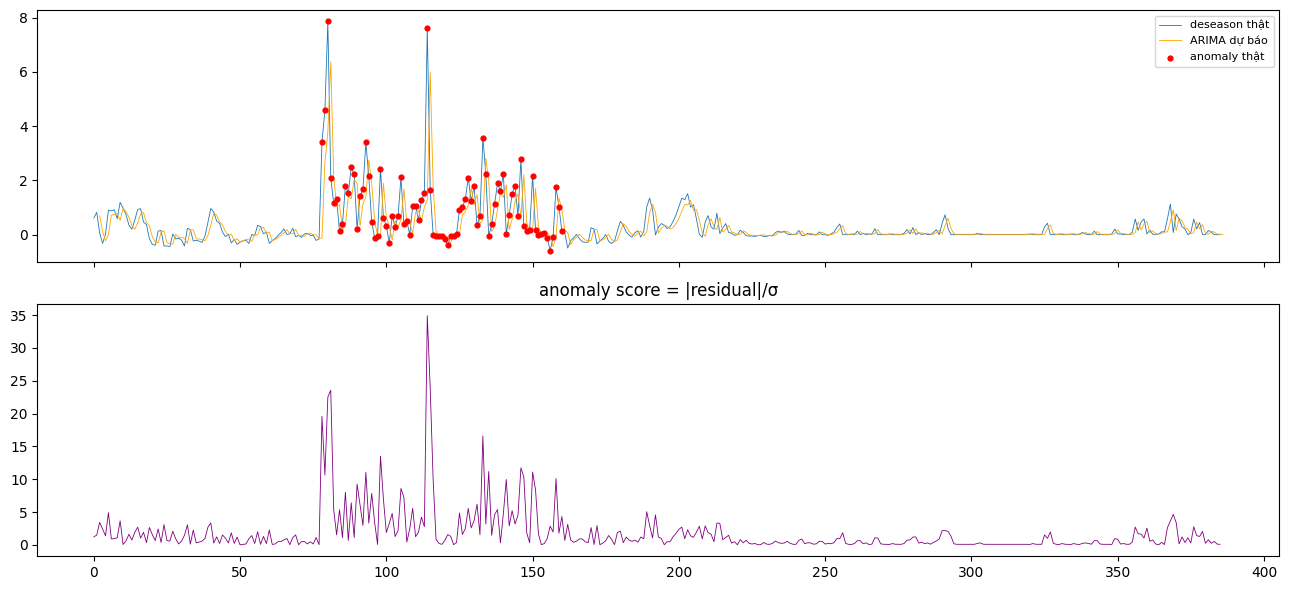

In [21]:
seg_view = p[(p.segment == seg_id) & (p.split == "test")].head(2000)
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(seg_view.deseason.values, lw=0.6, label="deseason thật")
ax[0].plot((mu + a1*(seg_view.deseason.shift(1)-mu) + a2*(seg_view.deseason.shift(2)-mu)).values,
           lw=0.6, color="orange", label="ARIMA dự báo")
ax[0].scatter(np.where(seg_view.label.values==1)[0], seg_view.deseason.values[seg_view.label.values==1],
              color="red", s=12, zorder=5, label="anomaly thật"); ax[0].legend(fontsize=8)
ax[1].plot(seg_view.score.values, lw=0.6, color="purple"); ax[1].set_title("anomaly score = |residual|/σ")
plt.tight_layout(); plt.show()